In [ ]:
# ==========================================
# Dataset QA Pipeline
# Project Echo
# Sprint 1
# ==========================================

## Environment Configuration and Dependency Check

This section verifies the execution environment before running the dataset quality assessment pipeline.

The code:
- Identifies the Python version and operating system.
- Checks the availability and versions of required Python packages.
- Confirms that the environment contains the necessary dependencies for audio processing, data analysis, and report generation.

Recording the environment details improves reproducibility by documenting the software versions used during dataset validation.

In [ ]:
import sys
import platform
import importlib
from pathlib import Path
import zipfile

def package_version(package):
    try:
        return importlib.import_module(package).__version__
    except Exception:
        return "Not Installed"

print("="*60)
print("Dataset QA Pipeline Environment")
print("="*60)

print(f"Python Version: {sys.version.split()[0]}")
print(f"Platform: {platform.system()} {platform.release()}")

print()

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "librosa",
    "soundfile",
    "scipy",
    "tqdm"
]

for package in packages:
    print(f"{package.capitalize()} Version: {package_version(package)}")

Dataset QA Pipeline Environment
Python Version: 3.12.13
Platform: Linux 6.6.122+

Numpy Version: 2.0.2
Pandas Version: 2.2.2
Matplotlib Version: 3.10.0
Seaborn Version: 0.13.2
Librosa Version: 0.11.0
Soundfile Version: 0.14.0
Scipy Version: 1.16.3
Tqdm Version: 4.67.3


This section detects whether the pipeline is being executed inside Google Colab.

If Colab is detected:
- Required Python packages are installed automatically.
- Audio processing and visualisation dependencies are prepared before running the dataset quality pipeline.

In [ ]:
#run this for colab only
try:
    import google.colab

    IN_COLAB = True

except ImportError:

    IN_COLAB = False

print(f"Running in Google Colab: {IN_COLAB}")

if IN_COLAB:

    !pip -q install librosa soundfile seaborn tqdm

Running in Google Colab: True


**Configuration**

This section defines the paths, dataset structure, and validation settings used by the dataset quality assessment pipeline.

The configuration:
- Sets the project working directory.
- Defines the expected dataset ZIP file and extracted dataset folder names.
- Automatically extracts the dataset archive if the dataset folder is not already available.
- Defines supported audio formats for validation.
- Sets audio duration thresholds used during quality checks.
- Defines the output location and report generation options.

The dataset loading process is designed to support reproducible execution across environments by allowing either:
- an existing extracted dataset folder, or
- a compressed dataset ZIP file that can be automatically extracted.

In [ ]:
# ==========================================
# CONFIGURATION
# ==========================================

 #change accordingly
PROJECT_ROOT = Path.cwd()

# Dataset names , provide the required file names
DATASET_ZIP_NAME = "datasets.zip"
DATASET_FOLDER_NAME = "datasets"


# Dataset locations
ZIP_PATH = PROJECT_ROOT / DATASET_ZIP_NAME
DATASET_PATH = PROJECT_ROOT / DATASET_FOLDER_NAME




if not DATASET_PATH.exists():

    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"No dataset found. Expected either:\n"
            f"1. Folder: {DATASET_PATH}\n"
            f"2. ZIP file: {ZIP_PATH}"
        )

    print("Extracting dataset ZIP...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(PROJECT_ROOT)


SUPPORTED_AUDIO_EXTENSIONS = [
    ".wav",
    ".mp3",
    ".flac",
    ".ogg",
    ".m4a"
]

MIN_DURATION = 1.0

MAX_DURATION = 10.0

REPORT_OUTPUT = PROJECT_ROOT / "reports"

GENERATE_CSV = True

GENERATE_TEXT_REPORT = True

Extracting dataset ZIP...


**Imports**

Import required libraries

In [ ]:
import os
import re
import json
import hashlib
import warnings

import librosa
import soundfile as sf
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

## **Data set discovery and manifest builder**

This section defines the dataset scanning component used to create an initial dataset manifest.

The scanner:
- Recursively searches the dataset directory and records all files.
- Captures key metadata including file name, path, extension, and file size.
- Checks whether the dataset follows the expected folder structure: dataset/
source/
species/
audio_file

- Identifies the dataset source and species labels from the directory structure.
- Flags inconsistent folder depths or missing source/species labels without deleting any records.

The output of this stage is a dataset manifest DataFrame that is used by later validation steps for audio quality checks, statistics generation, and reporting.

The source-aware structure allows the same pipeline to support multiple datasets (for example, GCP, iNaturalist, or ALA) without changing the validation logic.

In [ ]:
class DatasetScanner:

    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)


    def scan_files(self):
        """
        Scan every file in dataset.
        """

        records = []

        for file in self.dataset_path.rglob("*"):

            if file.is_file():

                relative = file.relative_to(self.dataset_path)

                records.append({

                    "file_name": file.name,

                    "absolute_path": str(file),

                    "relative_path": str(relative).replace("\\",
"/"),

                    "extension": file.suffix.lower(),

                    "size_bytes": file.stat().st_size

                })


        return pd.DataFrame(records)

    def check_paths(self, df):

        """
    Check for inconsistent folder structures.
    Expected format:
        dataset/source/species/audio_file
    Also checks whether all files have a consistent folder depth.
    """

        depths = []
        status = []

      # Count folder depth for every file
        for path in df["relative_path"]:
            depths.append(len(Path(path).parts))

      # Most common folder depth
        expected_depth = max(set(depths), key=depths.count)

      # Validate each path
        for path, depth in zip(df["relative_path"], depths):
            parts = Path(path).parts

            if len(parts) < 3:
                status.append("Missing source or species folder")

            elif parts[0] == "":
                status.append("Invalid species folder")

            elif depth != expected_depth:
                status.append(f"Inconsistent depth ({depth} levels)")

            else:
                status.append("OK")
        df["path_status"] = status

        return df

    def detect_species(self, df):
        """
        Expected structure:

        dataset/
            source/
                species/
                    audio_file

        Example:

        datasets/
            gcp/
                bird_001/
                    audio.wav

        Output:
            source = gcp
            species = bird_001
        """

        sources = []
        species = []

        for path in df["relative_path"]:

            parts = Path(path).parts

            if len(parts) >= 3:
                # source/species/file
                sources.append(parts[0])
                species.append(parts[1])

            elif len(parts) == 2:
                # species/file (fallback)
                sources.append("unknown")
                species.append(parts[0])

            else:
                sources.append("unknown")
                species.append("unknown")


        df["source"] = sources
        df["species"] = species

        return df



scanner = DatasetScanner(DATASET_PATH)


manifest = scanner.scan_files()

manifest = scanner.detect_species(manifest)


print("Files found:",len(manifest))

manifest.head()

#manifest.tail()

Files found: 46


,file_name,absolute_path,relative_path,extension,size_bytes,source,species
0,XC181330 - Red-browed Pardalote - Pardalotus r...,/content/datasets/XC181330 - Red-browed Pardal...,XC181330 - Red-browed Pardalote - Pardalotus r...,.mp3,146841,unknown,unknown
1,XC143502 - Brown Gerygone - Gerygone mouki ric...,/content/datasets/XC143502 - Brown Gerygone - ...,XC143502 - Brown Gerygone - Gerygone mouki ric...,.mp3,348254,unknown,unknown
2,XC36630 - Red-browed Pardalote - Pardalotus ru...,/content/datasets/XC36630 - Red-browed Pardalo...,XC36630 - Red-browed Pardalote - Pardalotus ru...,.mp3,206948,unknown,unknown
3,XC550699 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC550699 - Rose Robin - Petr...,XC550699 - Rose Robin - Petroica rosea.mp3,.mp3,538623,unknown,unknown
4,XC350439 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC350439 - Rose Robin - Petr...,XC350439 - Rose Robin - Petroica rosea.mp3,.mp3,141825,unknown,unknown


In [ ]:
# ==========================================
# SOURCE AND SPECIES COUNTS
# ==========================================

source_species_counts = (
    manifest
    .groupby(["source", "species"])
    .size()
    .reset_index(name="sample_count")
)


print(source_species_counts)



              source                    species  sample_count
0   project_data_gcp       Acanthiza reguloides             3
1   project_data_gcp              Asio_flammeus             3
2   project_data_gcp  Branta_bernical_nigricans             3
3   project_data_gcp               Capra Hircus             3
4   project_data_gcp               Ceyx azureus             3
5   project_data_gcp          Falco cenchroides             3
6   project_data_gcp           Lalage leucomela             3
7   project_data_gcp        Parvipsitta pusilla             4
8   project_data_gcp         Pezoporus wallicus             3
9   project_data_gcp                 Pitta iris             3
10  project_data_gcp       Spilopelia_chinensis             4
11  project_data_gcp        Stomiopera unicolor             3
12  project_data_gcp        Uperoleia altissima             3
13           unknown                    unknown             5


## **Structure validation**

This section standardises species labels to improve consistency during dataset analysis and reporting.

The normalisation process:
- Converts labels to lowercase.
- Removes leading and trailing whitespace.
- Replaces special characters and spaces with underscores.
- Removes repeated underscores.

This ensures that the same species is represented consistently even if the original folder names contain different formatting styles.

The cleaned `species_label` field is used for:
- Species-level sample counts.
- Source/species statistics.
- Dataset quality reports.
- Downstream analysis.

In [ ]:
# ==========================================
# LABEL NORMALISATION
# ==========================================
def normalise_label(name):

    name=str(name).lower().strip()

    name=re.sub(
        r"[^a-z0-9]+",
        "_",
        name
    )

    name=re.sub(
        r"_+",
        "_",
        name
    )

    return name.strip("_")



manifest["species_label"] = (
    manifest["species"]
    .apply(normalise_label)
)


manifest.head()

,file_name,absolute_path,relative_path,extension,size_bytes,source,species,species_label
0,XC181330 - Red-browed Pardalote - Pardalotus r...,/content/datasets/XC181330 - Red-browed Pardal...,XC181330 - Red-browed Pardalote - Pardalotus r...,.mp3,146841,unknown,unknown,unknown
1,XC143502 - Brown Gerygone - Gerygone mouki ric...,/content/datasets/XC143502 - Brown Gerygone - ...,XC143502 - Brown Gerygone - Gerygone mouki ric...,.mp3,348254,unknown,unknown,unknown
2,XC36630 - Red-browed Pardalote - Pardalotus ru...,/content/datasets/XC36630 - Red-browed Pardalo...,XC36630 - Red-browed Pardalote - Pardalotus ru...,.mp3,206948,unknown,unknown,unknown
3,XC550699 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC550699 - Rose Robin - Petr...,XC550699 - Rose Robin - Petroica rosea.mp3,.mp3,538623,unknown,unknown,unknown
4,XC350439 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC350439 - Rose Robin - Petr...,XC350439 - Rose Robin - Petroica rosea.mp3,.mp3,141825,unknown,unknown,unknown


This section performs automated checks on the dataset structure and file metadata.

The validation checks include:
- **Empty files:** Identifies files with zero size that may indicate incomplete or corrupted data.
- **Missing species labels:** Detects samples where species information could not be extracted from the folder structure.
- **Unsupported file formats:** Flags files that do not match the supported audio extensions defined in the configuration.

The function generates a structure validation report summarising the number of issues detected for each check.

These checks are performed for reporting purposes only. Records are not automatically removed, which preserves the original dataset and follows the Sprint 1 requirement of avoiding destructive cleaning.

In [ ]:
# ==========================================
# STRUCTURE VALIDATION
# ==========================================
def validate_structure(df):

    results=[]


    # Empty files

    empty_files=df[
        df["size_bytes"]==0
    ]


    results.append({

        "check":
        "Empty files",

        "count":
        len(empty_files)

    })


    # Missing labels

    missing_labels=df[
        df["species_label"]
        .isin(["unknown",""])
    ]


    results.append({

        "check":
        "Missing species labels",

        "count":
        len(missing_labels)

    })


    # Unsupported files

    unsupported=df[
        ~df.extension.isin(
            SUPPORTED_AUDIO_EXTENSIONS
        )
    ]


    results.append({

        "check":
        "Unsupported extensions",

        "count":
        len(unsupported)

    })


    return pd.DataFrame(results)



structure_report = validate_structure(manifest)


structure_report

,check,count
0,Empty files,0
1,Missing species labels,5
2,Unsupported extensions,1


## **Audio quality validation**

This section extends the dataset manifest with validation results rather than generating separate reports only.

The validation process includes:

- **Format validation:** Checks whether each file extension is supported by the pipeline and stores the result directly in the manifest using the `format_status` column.
- **Audio validation:** Attempts to load each audio file and extracts technical properties including:
  - Readability status.
  - Duration.
  - Sample rate.
  - Number of channels.
  - Audio quality issues such as invalid duration or unreadable files.

By adding these validation results directly to the manifest, every audio sample retains its original metadata together with its quality assessment results. This allows later reports to be generated from a single validated dataset table without modifying or removing records.

In [ ]:
#add the unsupported extension to the manifest
def validate_format(extension):

    if extension in SUPPORTED_AUDIO_EXTENSIONS:
        return "OK"

    else:
        return "unsupported_format"

manifest["format_status"] = (
    manifest["extension"]
    .apply(validate_format)
)

In [ ]:
# ==========================================
# AUDIO VALIDATION
# ==========================================


def validate_audio(path):

    result={

        "readable":False,

        "duration":None,

        "sample_rate":None,

        "channels":None,

        "issue":""

    }


    try:

        audio,sr = librosa.load(
            path,
            sr=None,
            mono=False
        )


        result["readable"]=True

        result["sample_rate"]=sr


        if audio.ndim==1:
            channels=1

        else:
            channels=audio.shape[0]


        result["channels"]=channels


        duration=librosa.get_duration(
            y=audio,
            sr=sr
        )


        result["duration"]=round(
            duration,
            3
        )


        if duration < MIN_DURATION:

            result["issue"]="too_short"


        elif duration > MAX_DURATION:

            result["issue"]="too_long"


    except Exception as e:

        result["issue"]="unreadable"



    return result

In [ ]:
# Run audio validation
audio_checks = (
    manifest["absolute_path"]
    .apply(validate_audio)
)

audio_checks = pd.DataFrame(audio_checks.tolist())

manifest = pd.concat(
    [manifest, audio_checks],
    axis=1
)

manifest.head()

/tmp/ipykernel_913/2353648396.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio,sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_913/2353648396.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio,sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


,file_name,absolute_path,relative_path,extension,size_bytes,source,species,species_label,format_status,readable,duration,sample_rate,channels,issue
0,XC181330 - Red-browed Pardalote - Pardalotus r...,/content/datasets/XC181330 - Red-browed Pardal...,XC181330 - Red-browed Pardalote - Pardalotus r...,.mp3,146841,unknown,unknown,unknown,OK,True,8.813,44100.0,2.0,
1,XC143502 - Brown Gerygone - Gerygone mouki ric...,/content/datasets/XC143502 - Brown Gerygone - ...,XC143502 - Brown Gerygone - Gerygone mouki ric...,.mp3,348254,unknown,unknown,unknown,OK,True,14.106,44100.0,2.0,too_long
2,XC36630 - Red-browed Pardalote - Pardalotus ru...,/content/datasets/XC36630 - Red-browed Pardalo...,XC36630 - Red-browed Pardalote - Pardalotus ru...,.mp3,206948,unknown,unknown,unknown,OK,True,12.564,44100.0,1.0,too_long
3,XC550699 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC550699 - Rose Robin - Petr...,XC550699 - Rose Robin - Petroica rosea.mp3,.mp3,538623,unknown,unknown,unknown,OK,True,24.465,44100.0,2.0,too_long
4,XC350439 - Rose Robin - Petroica rosea.mp3,/content/datasets/XC350439 - Rose Robin - Petr...,XC350439 - Rose Robin - Petroica rosea.mp3,.mp3,141825,unknown,unknown,unknown,OK,True,8.568,44100.0,2.0,


In [ ]:
print(manifest)

                                            file_name  \
0   XC181330 - Red-browed Pardalote - Pardalotus r...   
1   XC143502 - Brown Gerygone - Gerygone mouki ric...   
2   XC36630 - Red-browed Pardalote - Pardalotus ru...   
3          XC550699 - Rose Robin - Petroica rosea.mp3   
4          XC350439 - Rose Robin - Petroica rosea.mp3   
5                              region_0.500-2.499.wav   
6                              region_0.400-2.399.wav   
7                              region_3.149-4.448.wav   
8                              region_0.300-1.500.mp3   
9                              region_6.100-8.100.mp3   
10                           region_21.850-23.100.mp3   
11                                       XC554830.ogg   
12                                       XC666499.ogg   
13                                       XC522575.ogg   
14                           region_11.250-13.250.mp3   
15                         region_156.550-158.550.mp3   
16                           re

## **Data set statistics**

This section generates summary statistics describing the distribution of the dataset.

The analysis includes:

- **Species counts:** Calculates the number of audio samples available for each species label.
- **Source counts:** Calculates the number of samples contributed by each dataset source.

These statistics provide an overview of dataset composition and help identify:
- Species imbalance.
- Dominant or underrepresented sources.
- The overall distribution of available samples.

The counts are generated from the validated manifest, ensuring that all statistics are linked back to the original file metadata and quality assessment results.

In [ ]:
# ==========================================
# DATASET STATISTICS
# ==========================================


species_counts = (
    manifest
    .groupby("species_label")
    .size()
    .reset_index(
        name="file_count"
    )
)


species_counts.sort_values(
    "file_count",
    ascending=False
)

# Source-wise counts

source_counts = (
    manifest
    .groupby("source")
    .size()
    .reset_index(
        name="file_count"
    )
)


source_counts = source_counts.sort_values(
    "file_count",
    ascending=False
)

Final summary report  with all the chekcs

In [ ]:
def generate_summary():

    summary={

        "total_files":
        len(manifest),


        "species_count":
        manifest.species_label.nunique(),

        "source_count":
        manifest.source.nunique(),


        "unreadable_audio":
        sum(
            manifest.issue=="unreadable"
        ),


        "missing_labels":
        sum(
            manifest.species_label=="unknown"
        ),


        "empty_files":
        sum(
            manifest.size_bytes==0
        )

    }


    return pd.DataFrame(
        [summary]
    )


summary_report=generate_summary()


summary_report

,total_files,species_count,source_count,unreadable_audio,missing_labels,empty_files
0,46,14,2,2,5,0


## Acoustic Complexity Analysis

This section adds an additional acoustic analysis layer to evaluate general audio characteristics across different recordings.

The analysis generates quality indicators rather than performing species classification. The extracted features include:

- **Silence ratio:** Measures the proportion of the recording with very low energy, helping identify recordings dominated by silence.
- **Mean energy:** Represents the overall signal strength of the recording.
- **Energy variance:** Measures changes in signal intensity and identifies recordings with high variability.
- **Spectral centroid:** Estimates the frequency distribution of the audio signal and provides an indicator of acoustic characteristics.

A quality flag is assigned based on simple threshold rules:
- `HIGH_SILENCE` — recording contains a high proportion of silence.
- `LOW_SIGNAL` — recording has very low energy.
- `HIGH_VARIABILITY` — recording has large energy fluctuations.
- `GOOD` — recording passes the quality checks.

Any analysis errors are recorded in the output using the `error` field without stopping the pipeline. This allows problematic files to be identified while preserving all dataset records.

The output can be combined with source and species labels from the manifest to compare acoustic quality across different recordings and datasets.

In [ ]:
#add this analysis too as a addition - acoustic complexity with different sounds
def analyse_acoustic_complexity(
    file_path,
    sample_rate=16000
):
    """
    Analyse environmental audio complexity.
    Only generates quality indicators.
    """

    result = {
        "file_path": file_path,
        "silence_ratio": None,
        "mean_energy": None,
        "energy_variance": None,
        "spectral_centroid": None,
        "quality_flag": None,
        "error": None
    }


    try:

        audio, sr = librosa.load(
            file_path,
            sr=sample_rate,
            mono=True
        )


        # RMS energy
        rms = librosa.feature.rms(
            y=audio
        )[0]


        silence_ratio = np.mean(
            rms < 0.01
        )


        mean_energy = np.mean(rms)

        energy_variance = np.var(rms)


        spectral_centroid = np.mean(
            librosa.feature.spectral_centroid(
                y=audio,
                sr=sample_rate
            )
        )


        # Quality rules
        if silence_ratio > 0.8:

            flag = "HIGH_SILENCE"


        elif mean_energy < 0.01:

            flag = "LOW_SIGNAL"


        elif energy_variance > 0.05:

            flag = "HIGH_VARIABILITY"


        else:

            flag = "GOOD"


        result.update({

            "silence_ratio":
                round(float(silence_ratio),4),

            "mean_energy":
                round(float(mean_energy),6),

            "energy_variance":
                round(float(energy_variance),6),

            "spectral_centroid":
                round(float(spectral_centroid),3),

            "quality_flag":
                flag
        })


    except Exception as e:
        # Record audio analysis errors without stopping the pipeline.
        result["quality_flag"] = "ERROR"
        result["error"] = str(e)


    return result

/tmp/ipykernel_913/793240273.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_913/793240273.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


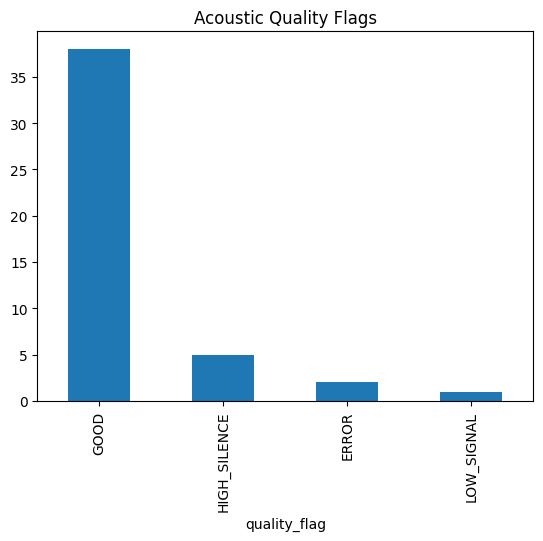

In [ ]:
acoustic_results = []


for _, row in manifest.iterrows():

    result = analyse_acoustic_complexity(
        row["absolute_path"]
    )

    result["species"] = row["species_label"]

    result["source"] = row["source"]

    acoustic_results.append(result)


acoustic_report = pd.DataFrame(
    acoustic_results
)

acoustic_report.head()

acoustic_report["quality_flag"].value_counts().plot(
    kind="bar",
    title="Acoustic Quality Flags"
)

plt.show()

In [ ]:
print(acoustic_report)

                                            file_path  silence_ratio  \
0   /content/datasets/XC181330 - Red-browed Pardal...         0.1884   
1   /content/datasets/XC143502 - Brown Gerygone - ...         0.1995   
2   /content/datasets/XC36630 - Red-browed Pardalo...         0.1679   
3   /content/datasets/XC550699 - Rose Robin - Petr...         0.0353   
4   /content/datasets/XC350439 - Rose Robin - Petr...         1.0000   
5   /content/datasets/project_data_gcp/Capra Hircu...         0.0000   
6   /content/datasets/project_data_gcp/Capra Hircu...         0.0000   
7   /content/datasets/project_data_gcp/Capra Hircu...         0.3415   
8   /content/datasets/project_data_gcp/Pitta iris/...         0.3333   
9   /content/datasets/project_data_gcp/Pitta iris/...         0.0000   
10  /content/datasets/project_data_gcp/Pitta iris/...         0.3659   
11  /content/datasets/project_data_gcp/Asio_flamme...         0.9931   
12  /content/datasets/project_data_gcp/Asio_flamme...         0.

## Report Generation and Export

This section saves all generated dataset quality reports to the configured output directory.

The exported reports include:

- **Dataset manifest:** Complete file-level metadata table containing paths, labels, formats, and validation results.
- **Structure report:** Summary of structural issues such as missing labels, empty files, and unsupported formats.
- **Species counts:** Number of samples available for each species label.
- **Source-species counts:** Distribution of samples across dataset sources and species combinations.
- **Acoustic complexity report:** Additional audio quality indicators including energy, silence, and spectral features.

Reports are saved as CSV files to allow easy inspection, sharing, and further analysis.

The original dataset is not modified or cleaned automatically. Instead, all quality findings are preserved as reports to support review and future processing decisions.

In [ ]:
REPORT_PATH = Path(REPORT_OUTPUT)

REPORT_PATH.mkdir(
    exist_ok=True
)

manifest.to_csv(
    REPORT_PATH /
    "dataset_manifest.csv",
    index=False
)


structure_report.to_csv(
    REPORT_PATH /
    "structure_report.csv",
    index=False
)


species_counts.to_csv(
    REPORT_PATH /
    "species_counts.csv",
    index=False
)

source_species_counts.to_csv(
    REPORT_OUTPUT / "source_species_counts.csv",
    index=False
)

acoustic_report.to_csv(
    REPORT_OUTPUT / "acoustic_complexity_report.csv",
    index=False
)

In [ ]:
#Sprint 1
#Raveesha Somawansa
#s225559348